# Student Performance — Supervised Regression mit `scikit-learn`

## Schritt 1: Werkzeuge laden

Ladet folgende Werkzeuge in eurem Python-Kernel:

* `read_csv` aus `pandas`
* `train_test_split` aus dem `model_selection`-Modul in `scikit-learn`
* `DecisionTreeRegressor` aus dem `tree`-Modul in `scikit-learn`
* `LinearRegression` aus dem `linear_model`-Modul in `scikit-learn`
* `PolynomialFeatures` aus dem `preprocessing`-Modul in `scikit-learn`
* `r2_score` aus dem `metrics`-Modul in `scikit-learn`
* `mean_absolute_error` aus dem `metrics`-Modul in `scikit-learn`
* `root_mean_squared_error` aus dem `metrics`-Modul in `scikit-learn`

In [51]:
# Daten einlesen
from pandas import read_csv

# Daten in Trainings- und Test-Set aufteilen
from sklearn.model_selection import train_test_split

# Werkzeuge zum Explorieren
from seaborn import pairplot, heatmap
from matplotlib import pyplot as plt

# Regressions-Modelle
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Feature-Erweiterung für die Polynomialregression
from sklearn.preprocessing import PolynomialFeatures

# Bewertungs-Metriken für Regression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error




## Schritt 2: Daten Laden

`student_performance_data.csv`-Datensatz in `pandas` laden. Datensatz beim Laden bereinigen, falls nötig.

In [52]:
# Laden: ";" als Trennzeichen, Beschreibungszeile (Zeile 0) überspringen, nur die 33 echten Spalten laden
df = read_csv("../data/student_performance_data.csv", sep=";", skiprows=[0], usecols=range(33))

# Zeilen mit fehlenden Werten entfernen
df = data.dropna()

df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000
mean,51.103774,2.509434,2.309748,1.572327,1.933962,0.218553,3.930818,3.177673,3.188679,1.506289,2.294025,3.542453,3.679245,11.421384,11.580189,11.913522
std,472.824419,1.134251,1.098302,0.750509,0.833573,0.586758,0.961426,1.044613,1.175443,0.931492,1.288359,1.442796,4.663236,2.746815,2.923947,3.240551
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,11237.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [53]:

import pandas as pd
import numpy as np

# CSV laden
df = pd.read_csv(
    "../data/student_performance_data.csv",
    sep=";",
    skiprows=1
)

# Leere Datenspalten und leere Zeilen droppen
df = df.dropna(axis=1, how="all")
df = df.dropna(axis=0, how="all")

# Spaltennamen bereinigen
df.columns = df.columns.str.strip()

# Strings bereinigen
for col in df.select_dtypes(include="object").columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace('"', '', regex=False)
    )

# Leere Strings wieder als NaN setzen
df = df.replace(["", "nan", "NaN", "None"], np.nan)

# Bekannte falsche Schreibweisen korrigieren
if "sex" in df.columns:
    df["sex"] = df["sex"].replace({
        "Female": "F",
        "female": "F",
        "Male": "M",
        "male": "M"
    })

# Erwartete Wertebereiche für numerische Spalten
numeric_ranges = {
    "age": (15, 22),
    "Medu": (0, 4),
    "Fedu": (0, 4),
    "traveltime": (1, 4),
    "studytime": (1, 4),
    "failures": (0, 3),
    "famrel": (1, 5),
    "freetime": (1, 5),
    "goout": (1, 5),
    "Dalc": (1, 5),
    "Walc": (1, 5),
    "health": (1, 5),
    "absences": (0, None),
    "G1": (0, 20),
    "G2": (0, 20),
    "G3": (0, 20)
}

# Numerische Spalten konvertieren
for col in numeric_ranges:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Fehlerhafte numerische Eingaben erkennen und als NaN markieren
invalid_values = {}

for col, (lower, upper) in numeric_ranges.items():
    if col in df.columns:
        invalid_mask = pd.Series(False, index=df.index)

        if lower is not None:
            invalid_mask |= df[col] < lower

        if upper is not None:
            invalid_mask |= df[col] > upper

        invalid_values[col] = df.loc[invalid_mask, col].dropna().unique().tolist()

        df.loc[invalid_mask, col] = np.nan

# Ausreißer über IQR-Methode erkennen
outlier_summary = {}

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)

    outlier_summary[col] = {
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_values": df.loc[outlier_mask, col].dropna().unique().tolist()
    }

# Übersicht fehlender Werte
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0]

# Ergebnisse anzeigen
print("Bereinigte Datenform:", df.shape)

print("\nFehlerhafte Werte außerhalb erwarteter Bereiche:")
display(pd.Series(invalid_values))

print("\nFehlende Werte nach Bereinigung:")
display(missing_values)

print("\nAusreißerübersicht nach IQR-Methode:")
display(pd.DataFrame(outlier_summary).T)

# ============================================================
# String-Spalten manuell in Integer umwandeln
# Prinzip: mapping_name = {"Kategorie": Zahl}
#          df["spalte"] = df["spalte"].map(mapping_name)
# ============================================================

mapping_school = {
    "GP": 0,
    "MS": 1
}
df["school"] = df["school"].map(mapping_school)


mapping_sex = {
    "F": 0,
    "M": 1
}
df["sex"] = df["sex"].map(mapping_sex)


mapping_address = {
    "R": 0,
    "U": 1
}
df["address"] = df["address"].map(mapping_address)


mapping_famsize = {
    "LE3": 0,
    "GT3": 1
}
df["famsize"] = df["famsize"].map(mapping_famsize)


mapping_Pstatus = {
    "A": 0,
    "T": 1
}
df["Pstatus"] = df["Pstatus"].map(mapping_Pstatus)


mapping_Mjob = {
    "at_home": 0,
    "health": 1,
    "other": 2,
    "services": 3,
    "teacher": 4
}
df["Mjob"] = df["Mjob"].map(mapping_Mjob)


mapping_Fjob = {
    "at_home": 0,
    "health": 1,
    "other": 2,
    "services": 3,
    "teacher": 4
}
df["Fjob"] = df["Fjob"].map(mapping_Fjob)


mapping_reason = {
    "course": 0,
    "home": 1,
    "other": 2,
    "reputation": 3
}
df["reason"] = df["reason"].map(mapping_reason)


mapping_guardian = {
    "father": 0,
    "mother": 1,
    "other": 2
}
df["guardian"] = df["guardian"].map(mapping_guardian)


mapping_schoolsup = {
    "no": 0,
    "yes": 1
}
df["schoolsup"] = df["schoolsup"].map(mapping_schoolsup)


mapping_famsup = {
    "no": 0,
    "yes": 1
}
df["famsup"] = df["famsup"].map(mapping_famsup)


mapping_paid = {
    "no": 0,
    "yes": 1
}
df["paid"] = df["paid"].map(mapping_paid)


mapping_activities = {
    "no": 0,
    "yes": 1
}
df["activities"] = df["activities"].map(mapping_activities)


mapping_nursery = {
    "no": 0,
    "yes": 1
}
df["nursery"] = df["nursery"].map(mapping_nursery)


mapping_higher = {
    "no": 0,
    "yes": 1
}
df["higher"] = df["higher"].map(mapping_higher)


mapping_internet = {
    "no": 0,
    "yes": 1
}
df["internet"] = df["internet"].map(mapping_internet)


mapping_romantic = {
    "no": 0,
    "yes": 1
}
df["romantic"] = df["romantic"].map(mapping_romantic)
# Bereinigten Datensatz anzeigen
display(df.head())


Bereinigte Datenform: (649, 33)

Fehlerhafte Werte außerhalb erwarteter Bereiche:


C:\Users\fabi0\AppData\Local\Temp\ipykernel_2812\2789290261.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


age           [1511.0, 1235.0, 1777.0, 11237.0, 999.0, 1991....
Medu                                                         []
Fedu                                                         []
traveltime                                                   []
studytime                                                    []
failures                                                     []
famrel                                                       []
freetime                                                     []
goout                                                        []
Dalc                                                         []
Walc                                                         []
health                                                       []
absences                                                     []
G1                                                           []
G2                                                           []
G3                                      


Fehlende Werte nach Bereinigung:


age           8
Mjob          8
Fjob          3
schoolsup     1
famsup        2
activities    1
nursery       1
internet      1
dtype: int64


Ausreißerübersicht nach IQR-Methode:


,lower_bound,upper_bound,outlier_count,outlier_values
age,13.0,21.0,1,[22.0]
Medu,-1.0,7.0,0,[]
Fedu,-2.0,6.0,0,[]
traveltime,-0.5,3.5,16,[4.0]
studytime,-0.5,3.5,35,[4.0]
failures,0.0,0.0,100,"[3.0, 1.0, 2.0]"
famrel,2.5,6.5,51,"[1.0, 2.0]"
freetime,1.5,5.5,45,[1.0]
goout,-1.0,7.0,0,[]
Dalc,-0.5,3.5,34,"[5.0, 4.0]"


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18.0,1,1,0,4.0,4.0,0.0,4.0,...,4.0,3.0,4.0,1.0,1.0,3.0,4.0,0.0,11.0,11.0
1,0,0,17.0,1,1,1,1.0,1.0,0.0,2.0,...,5.0,3.0,3.0,1.0,1.0,3.0,2.0,9.0,11.0,11.0
2,0,0,NaN,1,0,1,1.0,1.0,0.0,2.0,...,4.0,3.0,2.0,2.0,3.0,3.0,6.0,12.0,13.0,12.0
3,0,0,15.0,1,1,1,4.0,2.0,1.0,3.0,...,3.0,2.0,2.0,1.0,1.0,5.0,0.0,14.0,14.0,14.0
4,0,0,16.0,1,1,1,3.0,3.0,2.0,2.0,...,4.0,3.0,2.0,1.0,2.0,5.0,0.0,11.0,13.0,13.0


In [54]:
df.describe()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,641.000000,649.000000,649.000000,649.000000,649.000000,649.000000,641.000000,646.000000,...,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,0.348228,0.409861,16.747270,0.696456,0.704160,0.876733,2.514638,2.306626,1.959438,2.233746,...,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,0.476776,0.492187,1.216461,0.460143,0.456771,0.328996,1.134552,1.099931,1.244328,0.855175,...,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,16.000000,0.000000,0.000000,1.000000,2.000000,1.000000,1.000000,2.000000,...,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,0.000000,0.000000,17.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,4.000000,3.000000,3.000000,3.000000,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,1.000000,1.000000,22.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000,4.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


## Daten explorieren

In [55]:
def pairplot(df, chunk_size=4):
    # Nur numerische Spalten verwenden
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    # Optional: Zielvariable G3 ans Ende setzen
    if "G3" in numeric_cols:
        numeric_cols = [col for col in numeric_cols if col != "G3"] + ["G3"]

    # Pairplots in Blöcken erzeugen
    for i in range(0, len(numeric_cols), chunk_size):
        cols = numeric_cols[i:i + chunk_size]

        print(f"Pairplot für Spalten: {cols}")

        sns.pairplot(
            df[cols].dropna(),
            diag_kind="hist",
            corner=False
        )

        plt.show()

Pairplot für Spalten: ['school', 'sex', 'age', 'address']


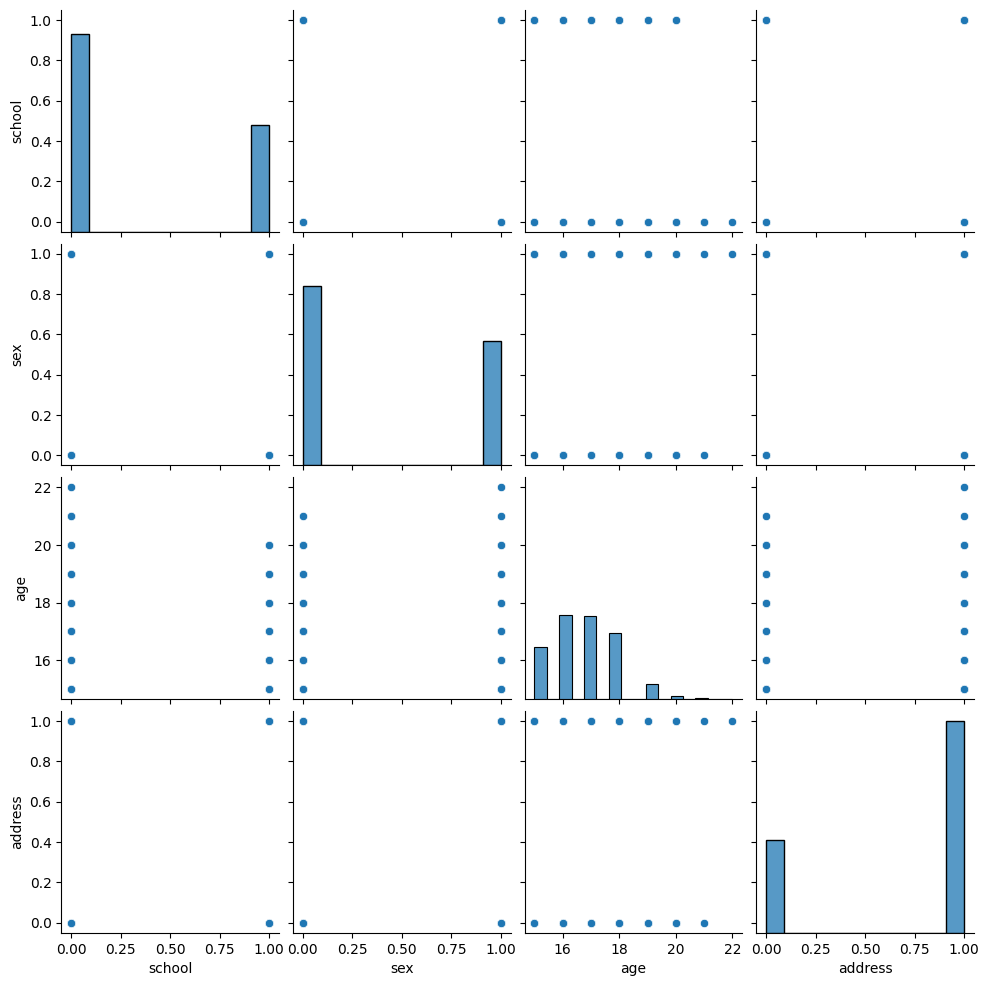

Pairplot für Spalten: ['famsize', 'Pstatus', 'Medu', 'Fedu']


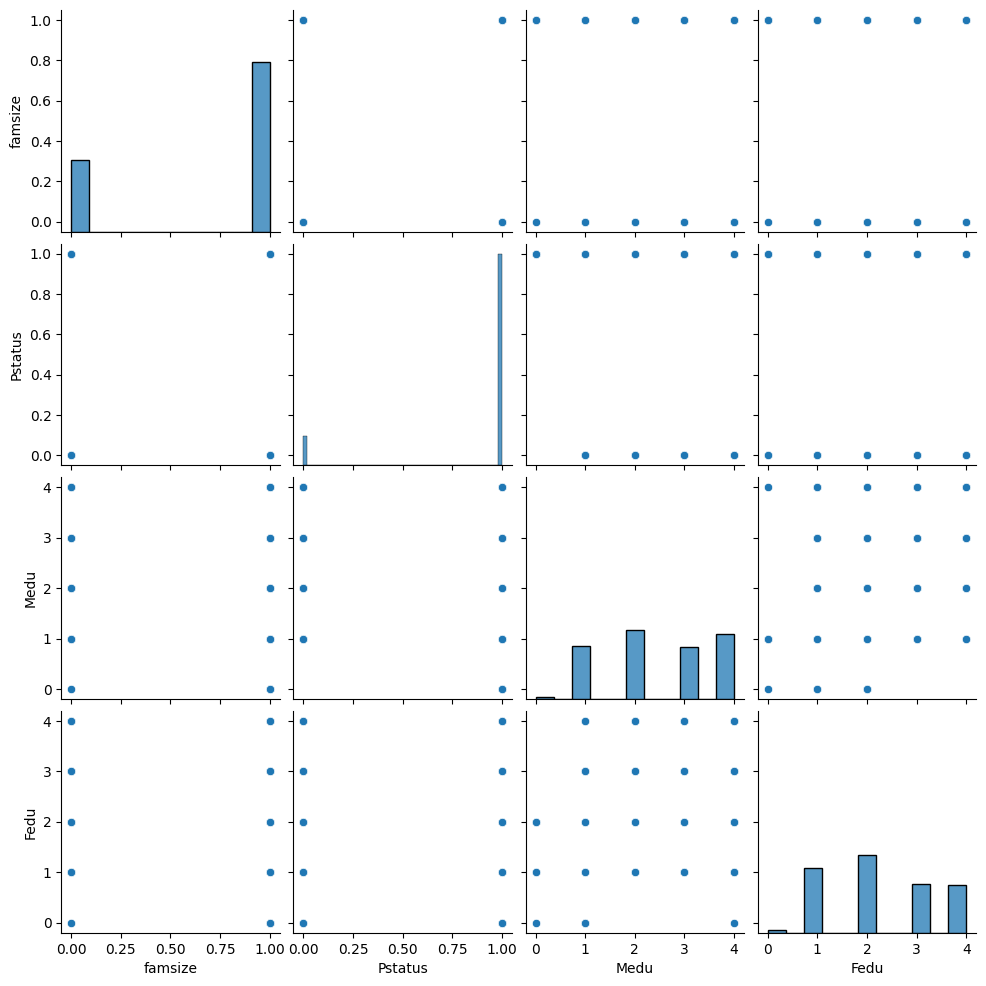

Pairplot für Spalten: ['Mjob', 'Fjob', 'reason', 'guardian']


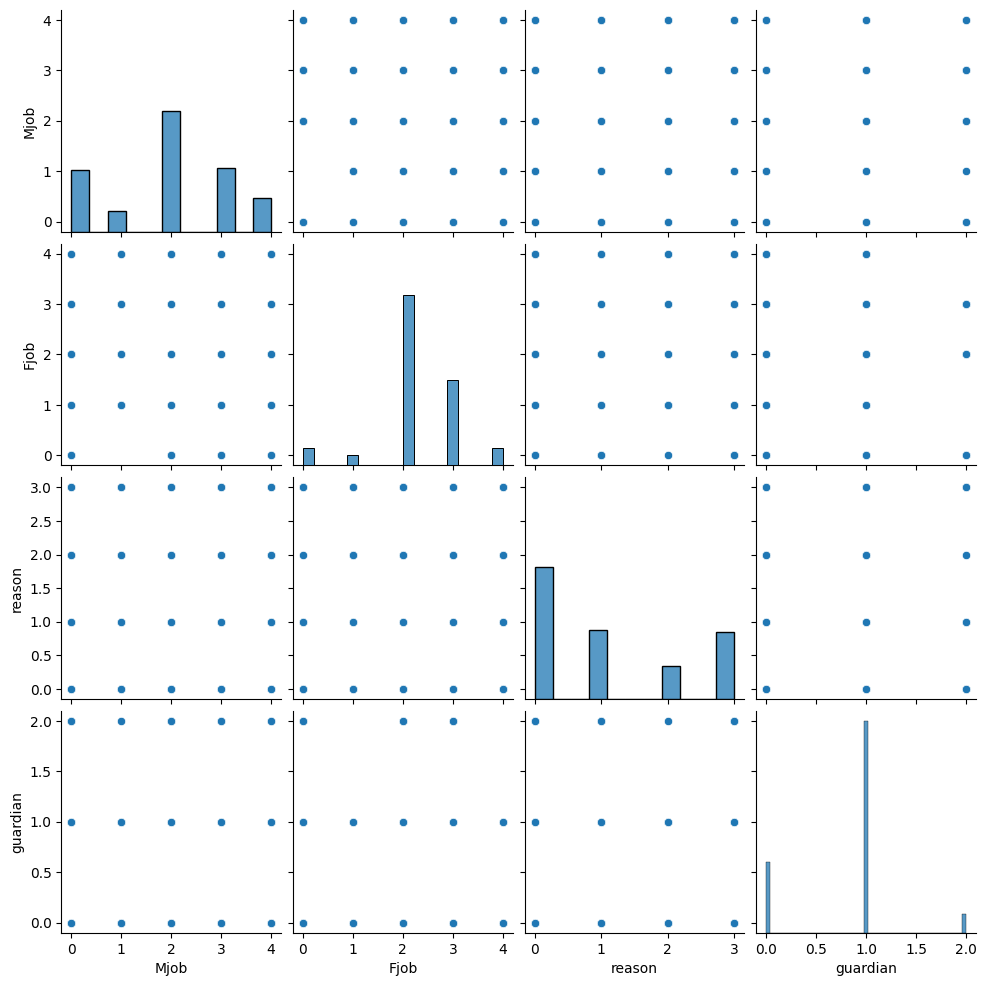

Pairplot für Spalten: ['traveltime', 'studytime', 'failures', 'schoolsup']


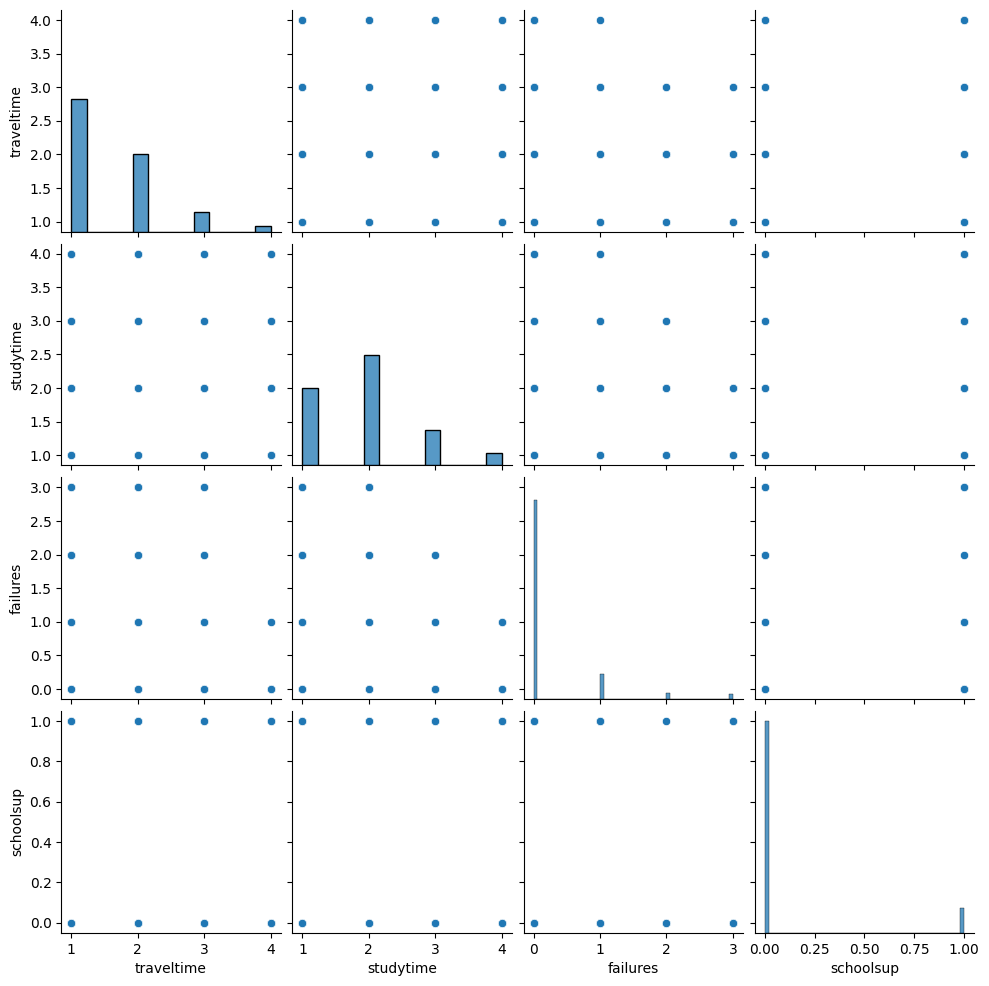

Pairplot für Spalten: ['famsup', 'paid', 'activities', 'nursery']


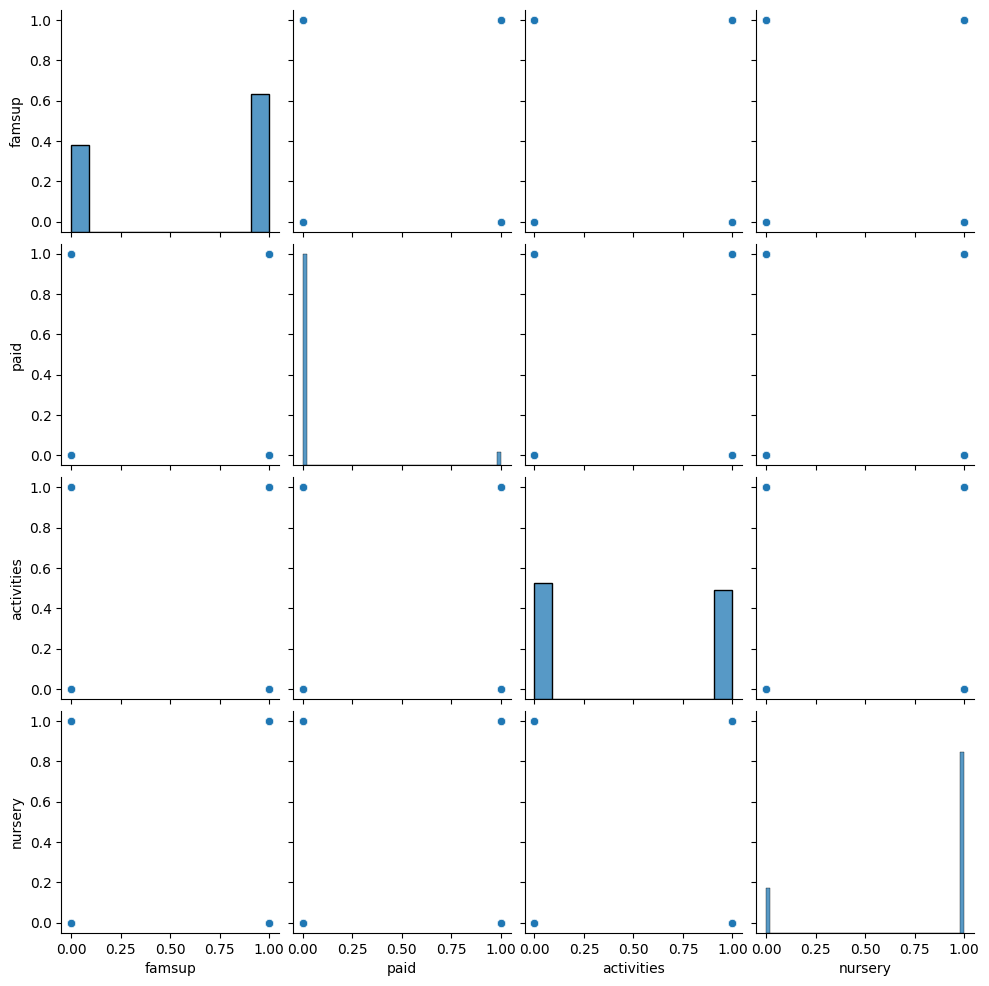

Pairplot für Spalten: ['higher', 'internet', 'romantic', 'famrel']


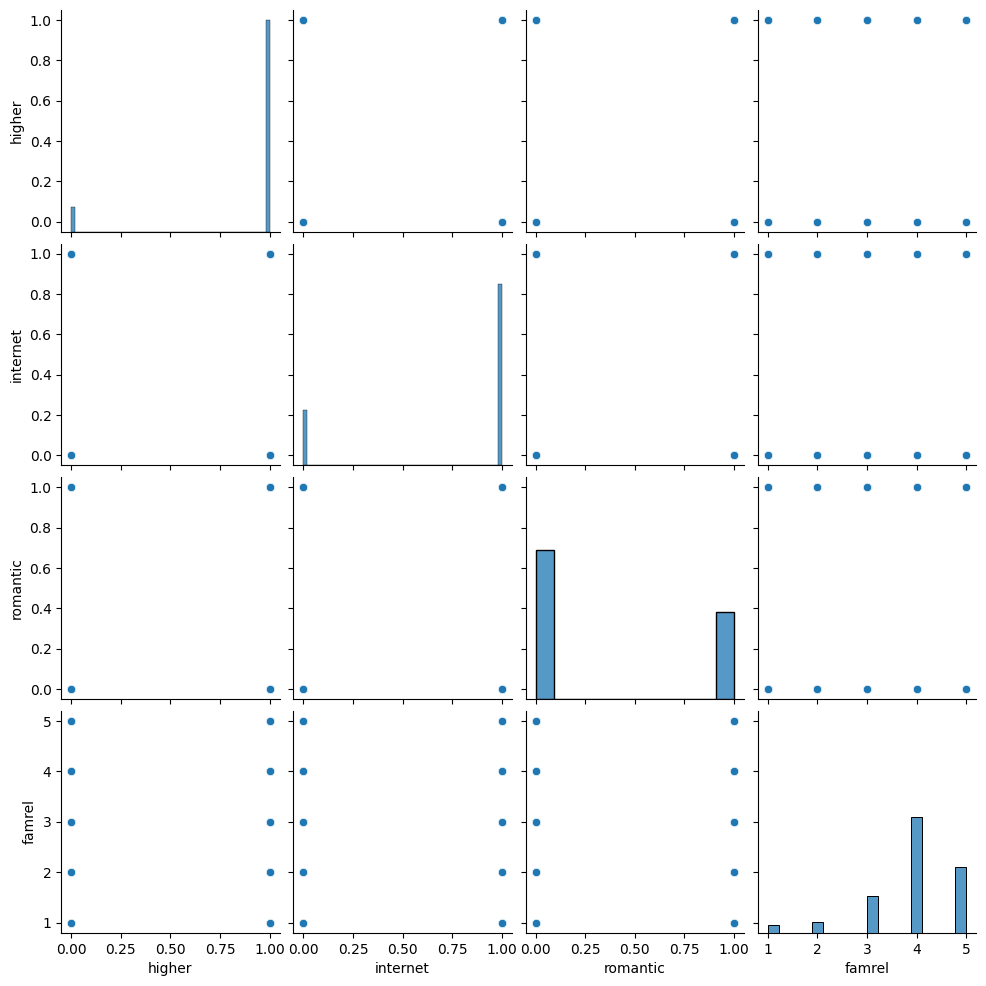

Pairplot für Spalten: ['freetime', 'goout', 'Dalc', 'Walc']


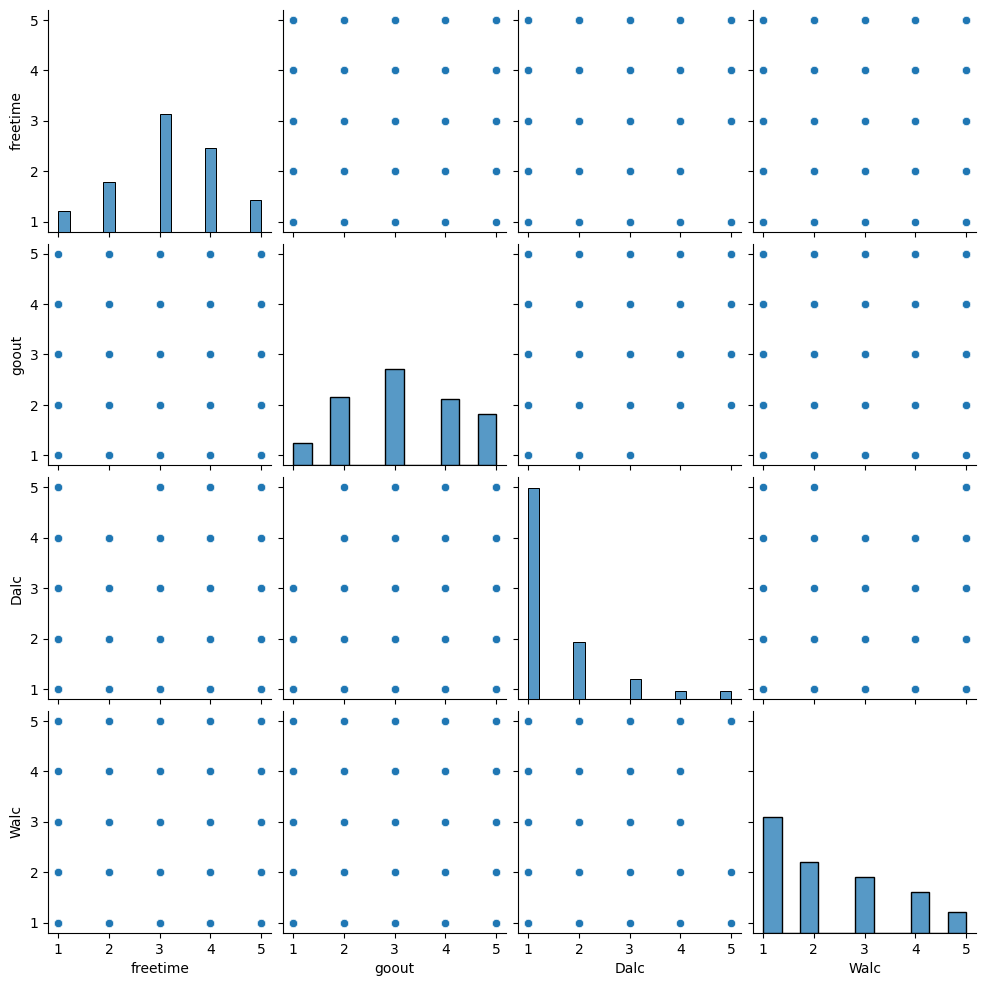

Pairplot für Spalten: ['health', 'absences', 'G1', 'G2']


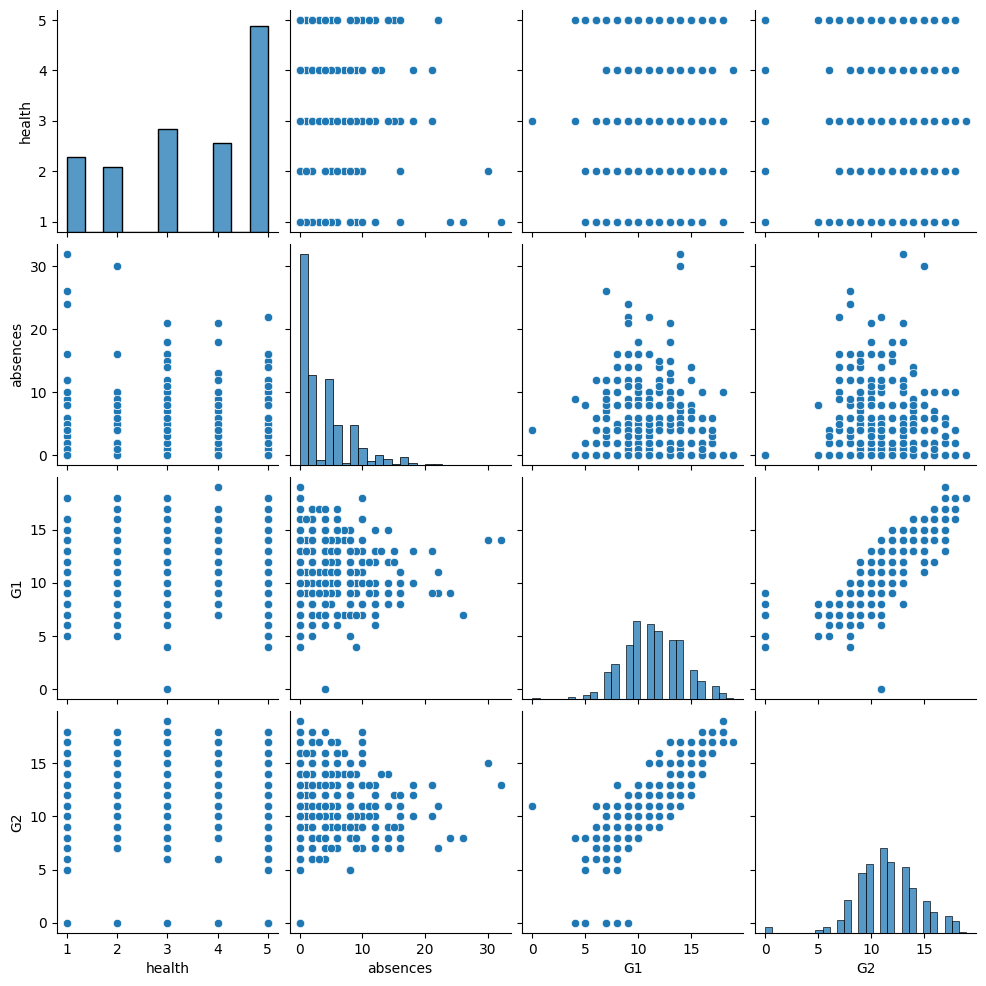

Pairplot für Spalten: ['G3']


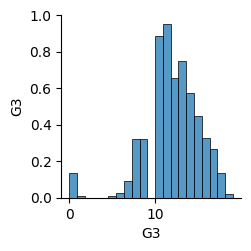

In [56]:
pairplot(df, chunk_size=4)

<Axes: >

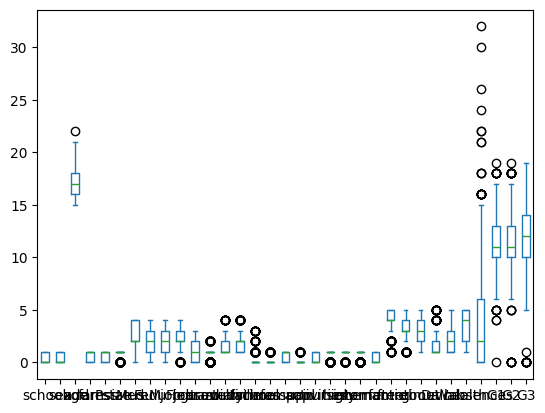

In [57]:
df.plot(kind="box")

In [58]:
"age, famsize, pstatus, medu, fedu, reason, traveltime, studytime, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic, famrel, freetime, goout, dalc, walc, health, absences"

'age, famsize, pstatus, medu, fedu, reason, traveltime, studytime, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic, famrel, freetime, goout, dalc, walc, health, absences'

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      649 non-null    int64  
 1   sex         649 non-null    int64  
 2   age         641 non-null    float64
 3   address     649 non-null    int64  
 4   famsize     649 non-null    int64  
 5   Pstatus     649 non-null    int64  
 6   Medu        649 non-null    float64
 7   Fedu        649 non-null    float64
 8   Mjob        641 non-null    float64
 9   Fjob        646 non-null    float64
 10  reason      649 non-null    int64  
 11  guardian    649 non-null    int64  
 12  traveltime  649 non-null    float64
 13  studytime   649 non-null    float64
 14  failures    649 non-null    float64
 15  schoolsup   648 non-null    float64
 16  famsup      647 non-null    float64
 17  paid        649 non-null    int64  
 18  activities  648 non-null    float64
 19  nursery     648 non-null    float64
 20 

## Daten bereinigung

In [61]:
X = df[[
 'age',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'reason',
 'traveltime',
  'studytime',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
  'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
  'health',
 'absences']]

y = df[
 'G3'
 ]